In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn


base_path = r"C:\Users\cdmas\Desktop\Numerical Experiment\ml-100k"

# Use u1.base / u1.test for real experiment later.
train_df = pd.read_csv(
    fr"{base_path}\u1.base",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

test_df = pd.read_csv(
    fr"{base_path}\u1.test",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

users = pd.read_csv(
    fr"{base_path}\u.user",
    sep="|",
    names=["user_id", "age", "gender", "occupation", "zip"]
)

items = pd.read_csv(
    fr"{base_path}\u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

item_columns = [
    "movie_id", "title", "release_date", "video_release_date", "IMDb_URL"
] + [f"genre_{i}" for i in range(19)]
items.columns = item_columns


# 2. Construct W: 943 x 21 (occupation one-hot)
n_users = 943
n_items = 1682

occupations = sorted(users["occupation"].unique())
occupation_to_idx = {occ: i for i, occ in enumerate(occupations)}
d1 = len(occupations)   # should be 21
d2 = 19                 # genres

W = np.zeros((n_users, d1), dtype=np.float32)
for _, row in users.iterrows():
    i = int(row["user_id"]) - 1
    j = occupation_to_idx[row["occupation"]]
    W[i, j] = 1.0


# 3. Construct Z: 1682 x 19 (genre indicators)
genre_cols = [f"genre_{i}" for i in range(19)]
Z = items[genre_cols].values.astype(np.float32)


# 4. Convert train/test observed entries to tensors
train_user_idx = torch.tensor(train_df["user_id"].values - 1, dtype=torch.long)
train_item_idx = torch.tensor(train_df["item_id"].values - 1, dtype=torch.long)
test_user_idx  = torch.tensor(test_df["user_id"].values - 1, dtype=torch.long)
test_item_idx  = torch.tensor(test_df["item_id"].values - 1, dtype=torch.long)

# Center ratings by training mean
train_mean = train_df["rating"].mean()

train_rating = torch.tensor(
    train_df["rating"].values - train_mean, dtype=torch.float32
)
test_rating = torch.tensor(
    test_df["rating"].values - train_mean, dtype=torch.float32
)

W_t = torch.tensor(W, dtype=torch.float32)
Z_t = torch.tensor(Z, dtype=torch.float32)


# 5. Projection matrices P_W, P_Z and orthogonal complements
def compute_projection_matrix(A: torch.Tensor) -> torch.Tensor:
    # A: n x d
    AtA = A.T @ A
    AtA_inv = torch.linalg.inv(AtA)
    return A @ AtA_inv @ A.T

P_W = compute_projection_matrix(W_t)                    # 943 x 943
P_Z = compute_projection_matrix(Z_t)                    # 1682 x 1682
I_users = torch.eye(n_users, dtype=torch.float32)
I_items = torch.eye(n_items, dtype=torch.float32)
P_W_perp = I_users - P_W
P_Z_perp = I_items - P_Z


# 6. Model
class ProjectedGMC(nn.Module):
    def __init__(self, n_users, n_items, d1, d2, r):
        super().__init__()
        self.A = nn.Parameter(0.01 * torch.randn(d1, d2))
        self.B = nn.Parameter(0.01 * torch.randn(n_items, d1))
        self.C = nn.Parameter(0.01 * torch.randn(n_users, d2))
        self.X = nn.Parameter(0.01 * torch.randn(n_users, r))
        self.Y = nn.Parameter(0.01 * torch.randn(n_items, r))

    def forward(self, W, Z):
        return (
            W @ self.A @ Z.T +
            W @ self.B.T +
            self.C @ Z.T +
            self.X @ self.Y.T
        )

    @torch.no_grad()
    def project_parameters(self, P_W_perp, P_Z_perp):
        # Enforce orthogonality constraints after each gradient step
        self.C.data = P_W_perp @ self.C.data
        self.X.data = P_W_perp @ self.X.data
        self.B.data = P_Z_perp @ self.B.data
        self.Y.data = P_Z_perp @ self.Y.data


# 7. Helper function
def rmse_on_entries(M_hat, user_idx, item_idx, target):
    pred = M_hat[user_idx, item_idx]
    return torch.sqrt(torch.mean((pred - target) ** 2))

def evaluate_full_rmse(model, W_t, Z_t, user_idx, item_idx, target, rating_mean):
    model.eval()
    with torch.no_grad():
        M_hat_centered = model(W_t, Z_t)
        pred_centered = M_hat_centered[user_idx, item_idx]
        pred = pred_centered + rating_mean
        true = target + rating_mean
        rmse = torch.sqrt(torch.mean((pred - true) ** 2))
    return rmse.item()


# 8. Training setup
r = 0
max_iter = 1000

# regularization strengths
lam_A = 1e-3
lam_B = 1e-2
lam_C = 1e-2
lam_XY = 1e-2

model = ProjectedGMC(n_users, n_items, d1, d2, r)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_train = len(train_df)

# project initialization once before training
model.project_parameters(P_W_perp, P_Z_perp)

# ===== history containers =====
iter_hist = []
loss_hist = []
train_hist = []
test_hist = []
test_orig_hist = []

# 9. Training loop: gradient step + projection
best_test_rmse = float("inf")
best_state = None
patience = 5
patience_counter = 0
best_iter = -1

for t in range(max_iter):
    model.train()
    optimizer.zero_grad()

    M_hat = model(W_t, Z_t)
    pred_train = M_hat[train_user_idx, train_item_idx]

    mse_loss = torch.mean((pred_train - train_rating) ** 2)

    reg_loss = (
        lam_A * torch.sum(model.A ** 2)
        + lam_B * torch.sum(model.B ** 2)
        + lam_C * torch.sum(model.C ** 2)
        + lam_XY * (torch.sum(model.X ** 2) + torch.sum(model.Y ** 2))
    ) / num_train

    loss = mse_loss + reg_loss

    loss.backward()
    optimizer.step()

    # Projection step
    model.project_parameters(P_W_perp, P_Z_perp)

    if t % 50 == 0:
        with torch.no_grad():
            M_hat_eval = model(W_t, Z_t)

            train_rmse = rmse_on_entries(
                M_hat_eval, train_user_idx, train_item_idx, train_rating
            ).item()

            test_rmse = rmse_on_entries(
                M_hat_eval, test_user_idx, test_item_idx, test_rating
            ).item()

            test_rmse_original = evaluate_full_rmse(
                model, W_t, Z_t, test_user_idx, test_item_idx, test_rating, train_mean
            )

        # ===== save history =====
        iter_hist.append(t)
        loss_hist.append(loss.item())
        train_hist.append(train_rmse)
        test_hist.append(test_rmse)
        test_orig_hist.append(test_rmse_original)

        if test_rmse < best_test_rmse:
            best_test_rmse = test_rmse
            best_iter = t
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        print(
            f"Iter {t:4d} | "
            f"Loss {loss.item():.6f} | "
            f"Train RMSE(centered) {train_rmse:.6f} | "
            f"Test RMSE(centered) {test_rmse:.6f} | "
            f"Test RMSE(original) {test_rmse_original:.6f} | "
            f"Best Test RMSE {best_test_rmse:.6f} at iter {best_iter}"
        )

        if patience_counter >= patience:
            print(f"Early stopping triggered at iter {t}.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Loaded best model from iter {best_iter} with test RMSE {best_test_rmse:.6f}")

# 10. Final fitted matrix
with torch.no_grad():
    M_hat_centered = model(W_t, Z_t)
    M_hat_final = M_hat_centered + train_mean   # predicted ratings on original scale

Iter    0 | Loss 1.250457 | Train RMSE(centered) 1.116808 | Test RMSE(centered) 1.152691 | Test RMSE(original) 1.152691 | Best Test RMSE 1.152691 at iter 0
Iter   50 | Loss 1.111825 | Train RMSE(centered) 1.053308 | Test RMSE(centered) 1.110615 | Test RMSE(original) 1.110615 | Best Test RMSE 1.110615 at iter 50
Iter  100 | Loss 1.009386 | Train RMSE(centered) 1.003787 | Test RMSE(centered) 1.081907 | Test RMSE(original) 1.081907 | Best Test RMSE 1.081907 at iter 100
Iter  150 | Loss 0.931410 | Train RMSE(centered) 0.964354 | Test RMSE(centered) 1.062320 | Test RMSE(original) 1.062320 | Best Test RMSE 1.062320 at iter 150
Iter  200 | Loss 0.870164 | Train RMSE(centered) 0.932187 | Test RMSE(centered) 1.048883 | Test RMSE(original) 1.048883 | Best Test RMSE 1.048883 at iter 200
Iter  250 | Loss 0.820808 | Train RMSE(centered) 0.905415 | Test RMSE(centered) 1.039676 | Test RMSE(original) 1.039676 | Best Test RMSE 1.039676 at iter 250
Iter  300 | Loss 0.780217 | Train RMSE(centered) 0.8827

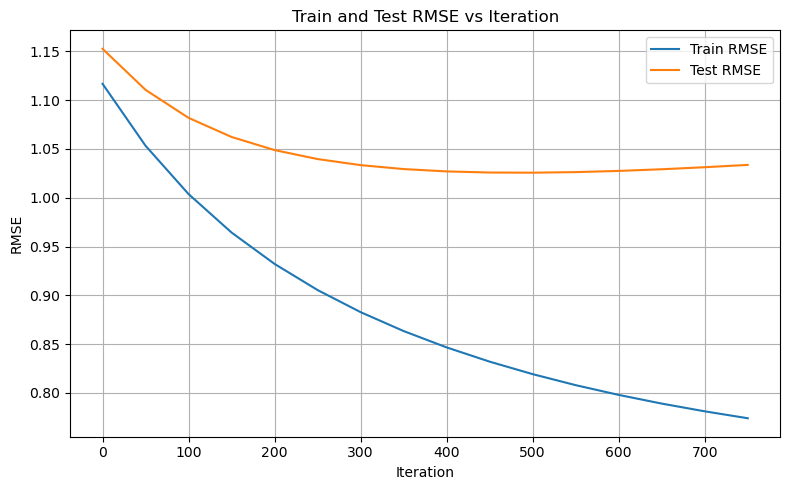

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(iter_hist, train_hist, label="Train RMSE")
plt.plot(iter_hist, test_hist, label="Test RMSE")
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("Train and Test RMSE vs Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

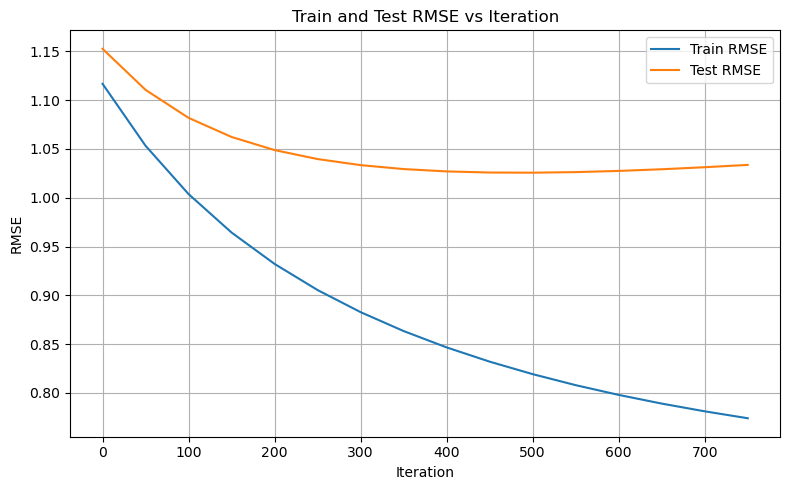

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(iter_hist, train_hist, label="Train RMSE")
plt.plot(iter_hist, test_hist, label="Test RMSE")
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("Train and Test RMSE vs Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

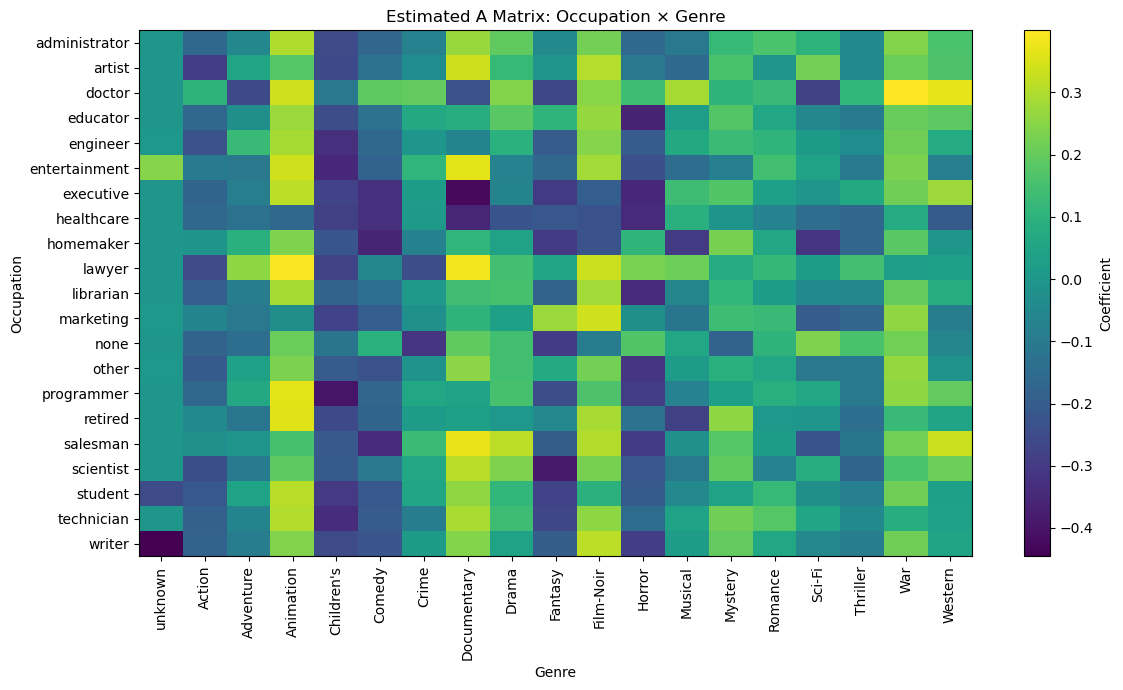

In [11]:
import matplotlib.pyplot as plt
import numpy as np

genre_names = [
    "unknown", "Action", "Adventure", "Animation", "Children's",
    "Comedy", "Crime", "Documentary", "Drama", "Fantasy",
    "Film-Noir", "Horror", "Musical", "Mystery", "Romance",
    "Sci-Fi", "Thriller", "War", "Western"
]

A_hat = model.A.detach().cpu().numpy()

plt.figure(figsize=(12, 7))
im = plt.imshow(A_hat, aspect="auto")
plt.colorbar(im, label="Coefficient")
plt.xticks(np.arange(len(genre_names)), genre_names, rotation=90)
plt.yticks(np.arange(len(occupations)), occupations)
plt.xlabel("Genre")
plt.ylabel("Occupation")
plt.title("Estimated A Matrix: Occupation × Genre")
plt.tight_layout()
plt.show()

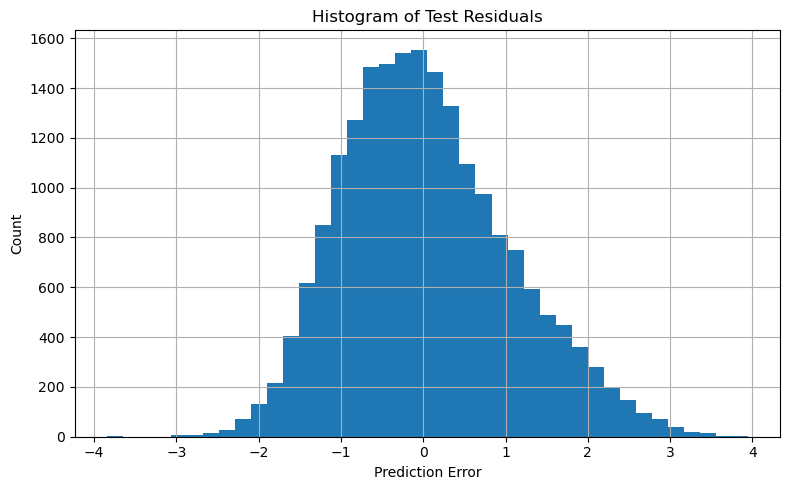

Residual mean: 0.042857252
Residual std : 1.0248175
Test RMSE    : 1.0257132
Test MAE     : 0.8170032


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch

with torch.no_grad():
    M_hat = model(W_t, Z_t) + train_mean
    pred_test = M_hat[test_user_idx, test_item_idx].cpu().numpy()
    true_test = (test_rating + train_mean).cpu().numpy()
    resid = pred_test - true_test

plt.figure(figsize=(8, 5))
plt.hist(resid, bins=40)
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Histogram of Test Residuals")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Residual mean:", np.mean(resid))
print("Residual std :", np.std(resid))
print("Test RMSE    :", np.sqrt(np.mean(resid**2)))
print("Test MAE     :", np.mean(np.abs(resid)))

In [13]:
import numpy as np

global_mean_pred = np.full(len(test_df), train_mean, dtype=np.float32)
true_test = test_df["rating"].values.astype(np.float32)

global_mean_rmse = np.sqrt(np.mean((global_mean_pred - true_test) ** 2))
print("Global mean test RMSE:", global_mean_rmse)

Global mean test RMSE: 1.153676


In [16]:
class CovariateOnlyModel(nn.Module):
    def __init__(self, n_users, n_items, d1, d2):
        super().__init__()
        self.A = nn.Parameter(0.01 * torch.randn(d1, d2))
        self.B = nn.Parameter(0.01 * torch.randn(n_items, d1))
        self.C = nn.Parameter(0.01 * torch.randn(n_users, d2))

    def forward(self, W, Z):
        return W @ self.A @ Z.T + W @ self.B.T + self.C @ Z.T

    @torch.no_grad()
    def project_parameters(self, P_W_perp, P_Z_perp):
        self.C.data = P_W_perp @ self.C.data
        self.B.data = P_Z_perp @ self.B.data

In [17]:
class LowRankOnlyModel(nn.Module):
    def __init__(self, n_users, n_items, r):
        super().__init__()
        self.X = nn.Parameter(0.01 * torch.randn(n_users, r))
        self.Y = nn.Parameter(0.01 * torch.randn(n_items, r))

    def forward(self, W, Z):
        return self.X @ self.Y.T

    @torch.no_grad()
    def project_parameters(self, P_W_perp, P_Z_perp):
        self.X.data = P_W_perp @ self.X.data
        self.Y.data = P_Z_perp @ self.Y.data

In [19]:
class FullModel(nn.Module):
    def __init__(self, n_users, n_items, d1, d2, r):
        super().__init__()
        self.A = nn.Parameter(0.01 * torch.randn(d1, d2))
        self.B = nn.Parameter(0.01 * torch.randn(n_items, d1))
        self.C = nn.Parameter(0.01 * torch.randn(n_users, d2))
        self.X = nn.Parameter(0.01 * torch.randn(n_users, r))
        self.Y = nn.Parameter(0.01 * torch.randn(n_items, r))

    def forward(self, W, Z):
        return (
            W @ self.A @ Z.T +
            W @ self.B.T +
            self.C @ Z.T +
            self.X @ self.Y.T
        )

    @torch.no_grad()
    def project_parameters(self, P_W_perp, P_Z_perp):
        self.C.data = P_W_perp @ self.C.data
        self.X.data = P_W_perp @ self.X.data
        self.B.data = P_Z_perp @ self.B.data
        self.Y.data = P_Z_perp @ self.Y.data

In [20]:
def train_and_evaluate(
    model,
    W_t,
    Z_t,
    train_user_idx,
    train_item_idx,
    train_rating,
    test_user_idx,
    test_item_idx,
    test_rating,
    train_mean,
    P_W_perp,
    P_Z_perp,
    num_train,
    lr=1e-3,
    max_iter=1000,
    eval_every=50,
    patience=5,
    lam_A=0.0,
    lam_B=0.0,
    lam_C=0.0,
    lam_XY=0.0,
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_test_rmse = float("inf")
    best_iter = -1
    best_state = None
    patience_counter = 0

    iter_hist, train_hist, test_hist = [], [], []

    if hasattr(model, "project_parameters"):
        model.project_parameters(P_W_perp, P_Z_perp)

    for t in range(max_iter):
        model.train()
        optimizer.zero_grad()

        M_hat = model(W_t, Z_t)
        pred_train = M_hat[train_user_idx, train_item_idx]
        mse_loss = torch.mean((pred_train - train_rating) ** 2)

        reg_loss = torch.tensor(0.0)

        if hasattr(model, "A"):
            reg_loss = reg_loss + lam_A * torch.sum(model.A ** 2)
        if hasattr(model, "B"):
            reg_loss = reg_loss + lam_B * torch.sum(model.B ** 2)
        if hasattr(model, "C"):
            reg_loss = reg_loss + lam_C * torch.sum(model.C ** 2)
        if hasattr(model, "X"):
            reg_loss = reg_loss + lam_XY * torch.sum(model.X ** 2)
        if hasattr(model, "Y"):
            reg_loss = reg_loss + lam_XY * torch.sum(model.Y ** 2)

        reg_loss = reg_loss / num_train
        loss = mse_loss + reg_loss

        loss.backward()
        optimizer.step()

        if hasattr(model, "project_parameters"):
            model.project_parameters(P_W_perp, P_Z_perp)

        if t % eval_every == 0:
            with torch.no_grad():
                M_hat_eval = model(W_t, Z_t)
                train_rmse = rmse_on_entries(
                    M_hat_eval, train_user_idx, train_item_idx, train_rating
                ).item()
                test_rmse = rmse_on_entries(
                    M_hat_eval, test_user_idx, test_item_idx, test_rating
                ).item()

            iter_hist.append(t)
            train_hist.append(train_rmse)
            test_hist.append(test_rmse)

            if test_rmse < best_test_rmse:
                best_test_rmse = test_rmse
                best_iter = t
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    with torch.no_grad():
        M_hat_final = model(W_t, Z_t) + train_mean
        pred_test = M_hat_final[test_user_idx, test_item_idx]
        true_test = test_rating + train_mean
        test_rmse_original = torch.sqrt(torch.mean((pred_test - true_test) ** 2)).item()

    return {
        "best_iter": best_iter,
        "best_test_rmse_centered": best_test_rmse,
        "best_test_rmse_original": test_rmse_original,
        "iter_hist": iter_hist,
        "train_hist": train_hist,
        "test_hist": test_hist,
        "model": model,
    }

In [22]:
results = {}
num_train = len(train_df)

# Covariate-only
cov_model = CovariateOnlyModel(n_users, n_items, d1, d2)
results["CovariateOnly"] = train_and_evaluate(
    cov_model,
    W_t, Z_t,
    train_user_idx, train_item_idx, train_rating,
    test_user_idx, test_item_idx, test_rating,
    train_mean,
    P_W_perp, P_Z_perp,
    num_train,
    lr=1e-3,
    max_iter=1000,
    eval_every=50,
    patience=5,
    lam_A=1e-3,
    lam_B=1e-2,
    lam_C=1e-2,
    lam_XY=0.0,
)

# Low-rank-only
lowrank_model = LowRankOnlyModel(n_users, n_items, r=2)
results["LowRankOnly_r2"] = train_and_evaluate(
    lowrank_model,
    W_t, Z_t,
    train_user_idx, train_item_idx, train_rating,
    test_user_idx, test_item_idx, test_rating,
    train_mean,
    P_W_perp, P_Z_perp,
    num_train,
    lr=1e-3,
    max_iter=1000,
    eval_every=50,
    patience=5,
    lam_A=0.0,
    lam_B=0.0,
    lam_C=0.0,
    lam_XY=1e-2,
)

# Full model
full_model = FullModel(n_users, n_items, d1, d2, r=2)
results["Full_r2"] = train_and_evaluate(
    full_model,
    W_t, Z_t,
    train_user_idx, train_item_idx, train_rating,
    test_user_idx, test_item_idx, test_rating,
    train_mean,
    P_W_perp, P_Z_perp,
    num_train,
    lr=1e-3,
    max_iter=1000,
    eval_every=50,
    patience=5,
    lam_A=1e-3,
    lam_B=1e-2,
    lam_C=1e-2,
    lam_XY=1e-2,
)
# 7. Print a summary table
summary_rows = [
    {"Model": "GlobalMean", "Test_RMSE": global_mean_rmse, "Best_Iter": None}
]

for name, out in results.items():
    summary_rows.append({
        "Model": name,
        "Test_RMSE": out["best_test_rmse_original"],
        "Best_Iter": out["best_iter"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Test_RMSE")
print(summary_df)

            Model  Test_RMSE  Best_Iter
1   CovariateOnly   1.025533      500.0
3         Full_r2   1.029835      450.0
2  LowRankOnly_r2   1.129400      550.0
0      GlobalMean   1.153676        NaN


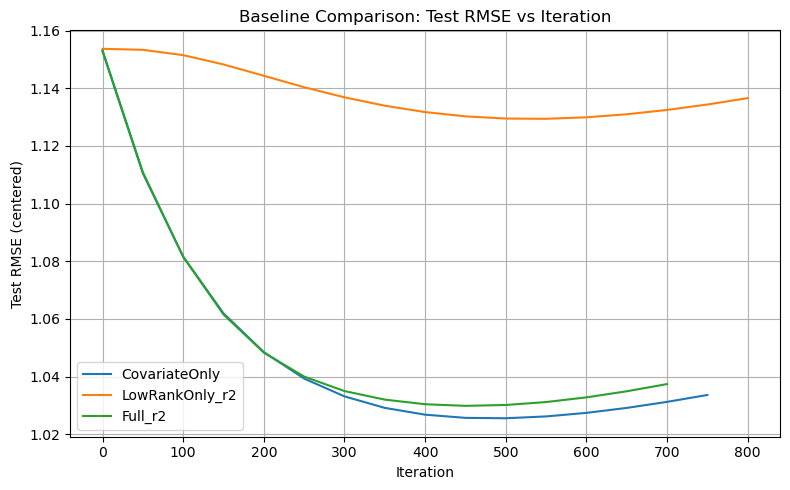

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for name, out in results.items():
    plt.plot(out["iter_hist"], out["test_hist"], label=name)

plt.xlabel("Iteration")
plt.ylabel("Test RMSE (centered)")
plt.title("Baseline Comparison: Test RMSE vs Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()